In [5]:
# Cell 1: Imports, Setup, and Helper Functions
from pathlib import Path
import json
import shutil
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.visualization import plot_pareto_front
import gc

# 1. Directories and Global Constants
data_base_dir = Path('data/regionwise_yearwise_samples')
artifact_dir = Path('data/feature_selection_artifacts')
output_config_dir = Path('data/optuna_regional_gee_configs')
output_config_dir.mkdir(parents=True, exist_ok=True)

TARGET_REGIONS = ['DES', 'IGP', 'WGR', 'ICR'] 
BENCHMARK_YEARS = [1990, 1995, 2000, 2002, 2006, 2013, 2019, 2024]

# 2. Class Remapping
old_codes = [5, 3, 4, 12, 11, 66, 19, 36, 9, 41, 24, 23, 75, 30, 25, 33, 76, 34, 61]
new_codes = [5, 3, 4, 12, 11, 66, 19, 14, 14, 14, 22, 22, 22, 22, 22, 33, 76, 34, 61]
class_remap_dict = dict(zip(old_codes, new_codes))

# 3. Reference Balancing Setup
ref_csv_path = Path('data/classwise_samples_reference_ratios.csv')
ref_df = pd.read_csv(ref_csv_path)
ref_df['old_code'] = old_codes
ref_df['new_code'] = new_codes
ref_region_cols = [c for c in ref_df.columns if c not in ['l2_code', 'l2_name', 'l1_parent', 'old_code', 'new_code']]
parent_ref_df = ref_df.groupby('new_code')[ref_region_cols].sum()

def get_balanced_indices(y_train_arr, target_n, ref_series, rng):
    classes = np.unique(y_train_arr)
    col_present = ref_series.reindex(classes).fillna(0.0)
    scaled = (np.sqrt(col_present) / sum(np.sqrt(col_present))) * target_n
    selected = []
    for cls in classes:
        cls_idx = np.where(y_train_arr == cls)[0]
        desired = int(np.round(scaled.get(cls, 0)))
        n_sample = min(len(cls_idx), max(3, desired))
        selected.extend(rng.choice(cls_idx, size=n_sample, replace=False))
    return np.array(selected)


🚀 STARTING PIPELINE FOR REGION: DES

[DES] Loaded 104 ranked features, 36 uncorrelated features.
[DES] Loading and caching benchmark years...


[I 2026-10-05 00:40:40,927] A new study created in memory with name: rf_DES



[DES] Executing Optuna Study...


/tmp/ipykernel_28986/2606491162.py:58: UserWarning: The distribution is specified by [0.1, 1.0] and step=0.2, but the range is not divisible by `step`. It will be replaced with [0.1, 0.9].
  train_fraction = trial.suggest_float("train_fraction", 0.10, 1.0, step=0.20)
[I 2026-10-05 00:44:04,190] Trial 0 finished with values: [0.870793371132885, 581596444800.0] and parameters: {'sampling_strategy': 'reference_balanced', 'feature_strategy': 'uncorrelated', 'train_fraction': 0.9, 'minLeafPopulation': 2, 'numberOfTrees': 50}.
/tmp/ipykernel_28986/2606491162.py:58: UserWarning: The distribution is specified by [0.1, 1.0] and step=0.2, but the range is not divisible by `step`. It will be replaced with [0.1, 0.9].
  train_fraction = trial.suggest_float("train_fraction", 0.10, 1.0, step=0.20)
[I 2026-10-05 00:57:22,328] Trial 1 finished with values: [0.9670876293436615, 1436719950000.0] and parameters: {'sampling_strategy': 'stratified', 'feature_strategy': 'all', 'max_input_features': 45, 'tra


[DES] Generating Pareto Html...


[DES] Exporting Trial Data to CSV/JSON...


/tmp/ipykernel_28986/2606491162.py:133: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_all_trials.to_json(output_config_dir / f"{region}_all_trials.json", orient="records", indent=4)


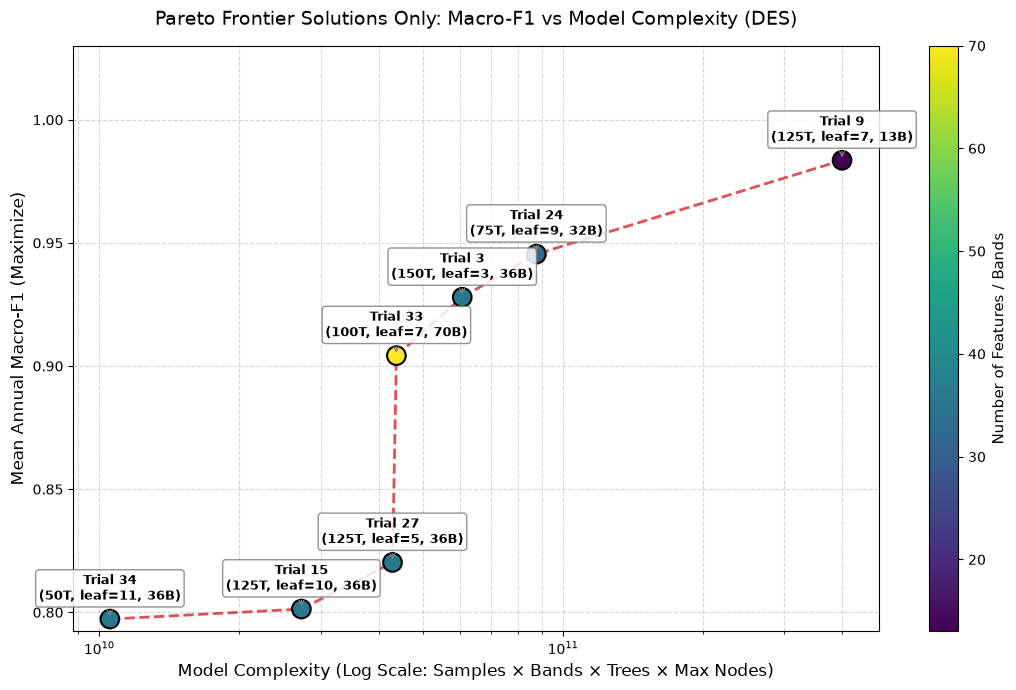


=== Pareto-Optimal Candidates Table for DES ===
 trial_number  macro_f1  model_complexity total_samples  num_features  trees  min_leaf feature_strat           sampling
           34  0.797266      1.053900e+10          None            36     50        11  uncorrelated reference_balanced
           15  0.801335      2.727493e+10          None            36    125        10  uncorrelated reference_balanced
           27  0.820258      4.287265e+10          None            36    125         5  uncorrelated reference_balanced
           33  0.904235      4.371118e+10          None            70    100         7           all         stratified
            3  0.927912      6.061521e+10          None            36    150         3  uncorrelated         stratified
           24  0.945451      8.758897e+10          None            32     75         9           all         stratified
            9  0.983542      3.995736e+11          None            13    125         7           all         st

FileNotFoundError: [Errno 2] No such file or directory: 'data/feature_selection_artifacts/IGP_ranked_features.json'

In [ ]:
# Cell 2: Master Pipeline (Data Prep -> Optuna -> Plotting -> Export)
for region in TARGET_REGIONS:
    print(f"\n{'='*70}")
    print(f"🚀 STARTING PIPELINE FOR REGION: {region}")
    print(f"{'='*70}\n")
    
    # --- STEP 1: Load Features ---
    with open(artifact_dir / f"{region}_ranked_features.json", "r") as f:
        all_ranked = json.load(f)["ranked_features"]
    with open(artifact_dir / f"{region}_uncorrelated_features.json", "r") as f:
        uncorr_ranked = json.load(f)["uncorrelated_features"]
    
    print(f"[{region}] Loaded {len(all_ranked)} ranked features, {len(uncorr_ranked)} uncorrelated features.")

    # --- STEP 2: Pre-Partition Data ---
    print(f"[{region}] Loading and caching benchmark years...")
    region_dir = data_base_dir / region
    cache_dir = Path(f'data/cache_splits_{region}')
    
    if cache_dir.exists():
        shutil.rmtree(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    
    for yr in BENCHMARK_YEARS:
        year_path = region_dir / f"year={yr}"
        df_yr = (
            pl.read_parquet(year_path / "*.parquet")
            .with_columns(pl.col('class').replace_strict(class_remap_dict, default=pl.col('class')).cast(pl.Int32))
            .select(all_ranked + ['class'])
        )
        
        X_yr = df_yr.select(all_ranked).to_numpy().astype(np.float32)
        y_yr = df_yr['class'].to_numpy().astype(np.int32)
        del df_yr
        gc.collect()
        
        X_tr, X_val, y_tr, y_val = train_test_split(X_yr, y_yr, test_size=0.20, stratify=y_yr, random_state=42)
        np.savez_compressed(cache_dir / f"split_{yr}.npz", X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val)
        del X_yr, y_yr, X_tr, X_val, y_tr, y_val
        gc.collect()

    # --- STEP 3: Optuna Optimization ---
    print(f"\n[{region}] Executing Optuna Study...")
    feat_to_idx = {name: i for i, name in enumerate(all_ranked)}
    ref_col_series = parent_ref_df[region] if region in parent_ref_df.columns else None

    def objective(trial):
        sampling_strategy = trial.suggest_categorical("sampling_strategy", ["stratified", "reference_balanced"])
        feat_strategy = trial.suggest_categorical("feature_strategy", ["all", "uncorrelated"])
        
        if feat_strategy == "uncorrelated":
            active_names = uncorr_ranked
        else:
            num_bands = trial.suggest_int("max_input_features", 10, len(all_ranked))
            active_names = all_ranked[:num_bands]
            
        active_col_idx = [feat_to_idx[f] for f in active_names]
        train_fraction = trial.suggest_float("train_fraction", 0.10, 1.0, step=0.20)
        min_leaf = trial.suggest_int("minLeafPopulation", 2, 12)
        n_trees = trial.suggest_int("numberOfTrees", 50, 150, step=25)

        rf_params = {
            "n_estimators": n_trees, "min_samples_leaf": min_leaf,
            "max_features": "sqrt", "max_depth": None,
            "n_jobs": 2, "random_state": 42
        }

        yearly_macro_f1s = []
        annual_training_sample_counts = []
        all_year_max_nodes = []
        rng = np.random.RandomState(42)

        for yr in BENCHMARK_YEARS:
            data = np.load(cache_dir / f"split_{yr}.npz")
            X_tr, y_tr, X_val, y_val = data['X_tr'], data['y_tr'], data['X_val'][:, active_col_idx], data['y_val']
            target_n = int(len(X_tr) * train_fraction)

            if train_fraction >= 0.99 and sampling_strategy == "stratified":
                chosen_local = np.arange(len(X_tr))
            elif sampling_strategy == "reference_balanced" and ref_col_series is not None:
                chosen_local = get_balanced_indices(y_tr, target_n, ref_col_series, rng)
            else:
                chosen_local = []
                for cls in np.unique(y_tr):
                    cls_indices = np.where(y_tr == cls)[0]
                    n_take = max(3, int(target_n * len(cls_indices) / len(y_tr)))
                    chosen_local.extend(rng.choice(cls_indices, size=min(len(cls_indices), n_take), replace=False))
                chosen_local = np.array(chosen_local)

            annual_training_sample_counts.append(len(chosen_local))
            X_sub, y_sub = X_tr[chosen_local][:, active_col_idx], y_tr[chosen_local]

            clf = RandomForestClassifier(**rf_params)
            clf.fit(X_sub, y_sub)

            all_year_max_nodes.append(max(tree.tree_.node_count for tree in clf.estimators_))
            yearly_macro_f1s.append(f1_score(y_val, clf.predict(X_val), average="macro"))

            del data, X_tr, y_tr, X_val, y_val, X_sub, y_sub, clf
            gc.collect()

        mean_macro_f1 = float(np.mean(yearly_macro_f1s))
        samples_per_year = int(np.mean(annual_training_sample_counts))
        max_nodes_observed = int(max(all_year_max_nodes))
        num_features = len(active_col_idx)
        single_model_complexity = float(samples_per_year * num_features * n_trees * max_nodes_observed)

        trial.set_user_attr("samples_per_year", samples_per_year)
        trial.set_user_attr("num_features", num_features)
        trial.set_user_attr("max_nodes", max_nodes_observed)
        trial.set_user_attr("model_complexity", single_model_complexity)

        return mean_macro_f1, single_model_complexity

    # Standard in-memory study
    study = optuna.create_study(
        study_name=f"rf_{region}", 
        directions=["maximize", "minimize"]
    )
    study.optimize(objective, n_trials=40, n_jobs=1)

    # --- STEP 4: Plotly Visualization ---
    print(f"\n[{region}] Generating Pareto Html...")
    fig_plotly = plot_pareto_front(study, target_names=["Mean Macro-F1", "Model Complexity"])
    fig_plotly.update_layout(title=f"Multi-Objective Pareto Front (F1 vs Model Complexity) - {region}", width=900, height=550)
    fig_plotly.write_html(output_config_dir / f"{region}_pareto_frontier.html")
    fig_plotly.show()

    # --- STEP 5: Data Export ---
    print(f"[{region}] Exporting Trial Data to CSV/JSON...")
    df_all_trials = study.trials_dataframe()
    df_all_trials.to_csv(output_config_dir / f"{region}_all_trials.csv", index=False)
    df_all_trials.to_json(output_config_dir / f"{region}_all_trials.json", orient="records", indent=4)

    # --- STEP 6: Matplotlib Custom Pareto Analysis ---
    pareto_records = []
    for t in study.best_trials:
        strat = t.params.get("feature_strategy", "all")
        n_feats = len(uncorr_ranked) if strat == "uncorrelated" else t.params.get("max_input_features", len(all_ranked))
            
        pareto_records.append({
            "trial_number": t.number,
            "macro_f1": float(t.values[0]),
            "model_complexity": float(t.values[1]),
            "samples_per_year": t.user_attrs.get("samples_per_year"),
            "num_features": t.user_attrs.get("num_features", n_feats),
            "max_nodes": t.user_attrs.get("max_nodes"),
            "trees": t.params.get("numberOfTrees"),
            "min_leaf": t.params.get("minLeafPopulation"),
            "sampling": t.params.get("sampling_strategy"),
            "feature_strat": strat,
            "train_fraction": t.params.get("train_fraction")
        })

    if pareto_records:
        df_pareto = pd.DataFrame(pareto_records).sort_values("model_complexity")
        df_pareto.to_csv(output_config_dir / f"{region}_pareto_frontier.csv", index=False)
        df_pareto.to_json(output_config_dir / f"{region}_pareto_frontier.json", orient="records", indent=4)

        fig, ax = plt.subplots(figsize=(11, 7))
        ax.plot(df_pareto["model_complexity"], df_pareto["macro_f1"], color="#d62728", linestyle="--", linewidth=2, alpha=0.8, zorder=2, label="Pareto Efficient Frontier")
        scatter = ax.scatter(df_pareto["model_complexity"], df_pareto["macro_f1"], c=df_pareto["num_features"], cmap="viridis", s=180, edgecolor="black", linewidth=1.5, zorder=3)
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Number of Features / Bands", fontsize=11)

        for _, row in df_pareto.iterrows():
            label_text = f"Trial {int(row['trial_number'])}\n({int(row['trees'])}T, leaf={int(row['min_leaf'])}, {int(row['num_features'])}B)"
            ax.annotate(
                label_text, xy=(row["model_complexity"], row["macro_f1"]), xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", color="gray", lw=0.8)
            )

        ax.set_xscale("log")
        ax.set_title(f"Pareto Frontier Solutions Only: Macro-F1 vs Model Complexity ({region})", fontsize=14, pad=15)
        ax.set_xlabel("Model Complexity (Log Scale: Samples × Bands × Trees × Max Nodes)", fontsize=12)
        ax.set_ylabel("Mean Annual Macro-F1 (Maximize)", fontsize=12)
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

        y_margin = (df_pareto["macro_f1"].max() - df_pareto["macro_f1"].min()) * 0.25
        ax.set_ylim(df_pareto["macro_f1"].min() - 0.005, df_pareto["macro_f1"].max() + y_margin)

        plt.tight_layout()
        plt.savefig(output_config_dir / f"{region}_pareto_only_frontier.png", dpi=300, bbox_inches="tight")
        plt.show()

        print(f"\n=== Pareto-Optimal Candidates Table for {region} ===")
        display_cols = ["trial_number", "macro_f1", "model_complexity", "samples_per_year", "num_features", "trees", "min_leaf", "feature_strat", "sampling"]
        print(df_pareto[display_cols].to_string(index=False))

    print(f"\n[{region}] Pipeline Complete!\n")
    gc.collect()